### Utility-Based Metrics
Standard metrics (MSE, MAE) ignore the importance of rare extreme delays.  
Following the imbalanced regression literature, we implement:

$$prec^\phi = \frac{\sum_i \phi(\hat{y}_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(\hat{y}_i)}$$

$$rec^\phi = \frac{\sum_i \phi(y_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(y_i)}$$

$$F_1^\phi = \frac{2 \cdot prec^\phi \cdot rec^\phi}{prec^\phi + rec^\phi}$$

Where $\theta$ is an acceptable error tolerance (default: 30 min).

In [1]:
import joblib

print("Loading data from disk...")
pipeline_inputs = joblib.load('pipeline_inputs.joblib')

datasets = pipeline_inputs['datasets']
X_test   = pipeline_inputs['X_test']
y_test   = pipeline_inputs['y_test']
phi_test = pipeline_inputs['phi_test']

print("Successfully loaded data!")

Loading data from disk...
Successfully loaded data!


### Model Definitions
- **Linear Regression** - baseline linear model  
- **SVR** - support vector regression (with scaling pipeline)  
- **SVR2** - approximate kernel SVR using Nyström feature map + SGD, trading exact kernel computation for linear scalability 
- **Random Forest** - ensemble of decision trees  
- **LightGBM** - gradient boosted trees (extra benchmark)

In [2]:
import pickle
import os

all_results = {}
all_models = {}

model_names = ['LinearRegression', 'SVR', 'SVR2', 'LightGBM', 'RandomForest']

trained_dir    = 'trained'
evaluation_dir = 'evaluation'

for model_name in model_names:
    model_files = sorted([
        f for f in os.listdir(trained_dir)
        if f.startswith(f'{model_name}_sample') and f.endswith('.pkl')
    ])

    for fname in model_files:
        # extract sample tag: "{model_name}_sample{tag}.pkl" -> "0_5", "1_0", etc.
        sample_tag = fname[len(f'{model_name}_sample'):-len('.pkl')]

        models_path  = os.path.join(trained_dir,    fname)
        results_path = os.path.join(evaluation_dir, fname)

        if os.path.exists(models_path):
            with open(models_path, 'rb') as f:
                saved_models = pickle.load(f)
            for strategy, model in saved_models.items():
                all_models[(model_name, sample_tag, strategy)] = model
            print(f'  Loaded models  : {model_name} sample={sample_tag} — {len(saved_models)} strategies')

        if os.path.exists(results_path):
            with open(results_path, 'rb') as f:
                model_results = pickle.load(f)
            for strategy, metrics in model_results.items():
                all_results[(model_name, sample_tag, strategy)] = metrics
            print(f'  Loaded results : {model_name} sample={sample_tag} — {len(model_results)} strategies')
all_results = dict(
    sorted(all_results.items(), key=lambda x: (model_names.index(x[0][0]), x[0][1], x[0][2]))
)
print(f'\nTotal models  loaded: {len(all_models)}')
print(f'Total results loaded: {len(all_results)}')

  Loaded models  : LinearRegression sample=0_1 — 6 strategies
  Loaded results : LinearRegression sample=0_1 — 6 strategies
  Loaded models  : LinearRegression sample=0_25 — 6 strategies
  Loaded results : LinearRegression sample=0_25 — 6 strategies
  Loaded models  : LinearRegression sample=0_5 — 6 strategies
  Loaded results : LinearRegression sample=0_5 — 6 strategies
  Loaded models  : LinearRegression sample=1_0 — 6 strategies
  Loaded results : LinearRegression sample=1_0 — 6 strategies
  Loaded models  : SVR sample=0_0002 — 1 strategies
  Loaded results : SVR sample=0_0002 — 1 strategies
  Loaded models  : SVR sample=0_001 — 1 strategies
  Loaded results : SVR sample=0_001 — 1 strategies
  Loaded models  : SVR sample=1e-05 — 6 strategies
  Loaded results : SVR sample=1e-05 — 6 strategies
  Loaded models  : SVR sample=5e-05 — 6 strategies
  Loaded results : SVR sample=5e-05 — 6 strategies
  Loaded models  : SVR sample=_0_0001 — 6 strategies
  Loaded results : SVR sample=_0_0001 —

### Results Table

In [3]:
import pandas as pd

results_df = pd.DataFrame(all_results).T
results_df.index.names = ['Model', 'Sample', 'Strategy']
results_df = results_df[[
    'f1_phi', 'prec_phi', 'rec_phi',
    'Weighted_MAE', 'MAE', 'RMSE',
    'Tail_MAE', 'Tail_RMSE', 'tail_n'
]]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(results_df.round(4))

f1_phi  prec_phi  rec_phi  Weighted_MAE  \
Model            Sample  Strategy                                              
LinearRegression 0_1     Baseline    0.8544    0.8907   0.8209       30.0667   
                         GaussNoise  0.2016    0.1609   0.2698       42.7935   
                         RO          0.5421    0.4694   0.6415       34.6693   
                         RU          0.6868    0.6453   0.7340       33.1158   
                         SMOTER      0.5330    0.4593   0.6350       34.6049   
                         WERCS       0.7375    0.7123   0.7645       32.7856   
                 0_25    Baseline    0.8544    0.8908   0.8209       30.0759   
                         GaussNoise  0.2018    0.1609   0.2708       42.7736   
                         RO          0.5425    0.4698   0.6417       34.6600   
                         RU          0.6854    0.6434   0.7333       33.1442   
                         SMOTER      0.5323    0.4585   0.6345       34.6209   
                         WERCS       0.7352    0.7093   0.7631       32.7828   
                 0_5     Baseline    0.8544    0.8907   0.8209       30.0770   
                         GaussNoise  0.2021    0.1608   0.2717       42.7641   
                         RO          0.5429    0.4702   0.6420       34.6609   
                         RU          0.6864    0.6447   0.7339       33.1442   
                         SMOTER      0.5329    0.4591   0.6349       34.6218   
                         WERCS       0.7332    0.7066   0.7619       32.7863   
                 1_0     Baseline    0.8544    0.8908   0.8210       30.0779   
                         GaussNoise  0.2020    0.1608   0.2715       42.7609   
                         RO          0.5425    0.4698   0.6418       34.6640   
                         RU          0.6869    0.6453   0.7342       33.1410   
                         SMOTER      0.5333    0.4595   0.6352       34.6215   
                         WERCS       0.7322    0.7053   0.7613       32.7866   
SVR              0_0002  SMOTER      0.8416    0.8804   0.8062       29.6149   
                 0_001   SMOTER      0.8412    0.8791   0.8065       29.5318   
                 1e-05   Baseline    0.8414    0.8866   0.8006       29.6888   
                         GaussNoise  0.7223    0.6925   0.7547       32.8736   
                         RO          0.8467    0.8877   0.8093       29.7745   
                         RU          0.8453    0.8934   0.8021       29.8045   
                         SMOTER      0.8453    0.8876   0.8070       29.7299   
                         WERCS       0.8428    0.8865   0.8032       29.7334   
                 5e-05   Baseline    0.8398    0.8844   0.7995       29.6415   
                         GaussNoise  0.7544    0.7392   0.7703       31.6921   
                         RO          0.8452    0.8871   0.8071       29.7153   
                         RU          0.8430    0.8870   0.8032       29.7308   
                         SMOTER      0.8473    0.8868   0.8112       29.7200   
                         WERCS       0.8402    0.8823   0.8020       29.6694   
                 _0_0001 Baseline    0.8401    0.8853   0.7994       29.6381   
                         GaussNoise  0.7408    0.7200   0.7628       31.8589   
                         RO          0.8420    0.8829   0.8047       29.6549   
                         RU          0.8439    0.8869   0.8048       29.6809   
                         SMOTER      0.8447    0.8841   0.8086       29.6704   
                         WERCS       0.8399    0.8822   0.8014       29.6696   
SVR2             0_05    Baseline    0.8367    0.8760   0.8009       29.6622   
                         GaussNoise  0.8679    0.9006   0.8375       31.7204   
                         RO          0.8348    0.8733   0.7995       29.6616   
                         RU          0.8354    0.8739   0.8001       29.6621   
                         SMOTER      

### F₁φ Heatmap - Model × Strategy

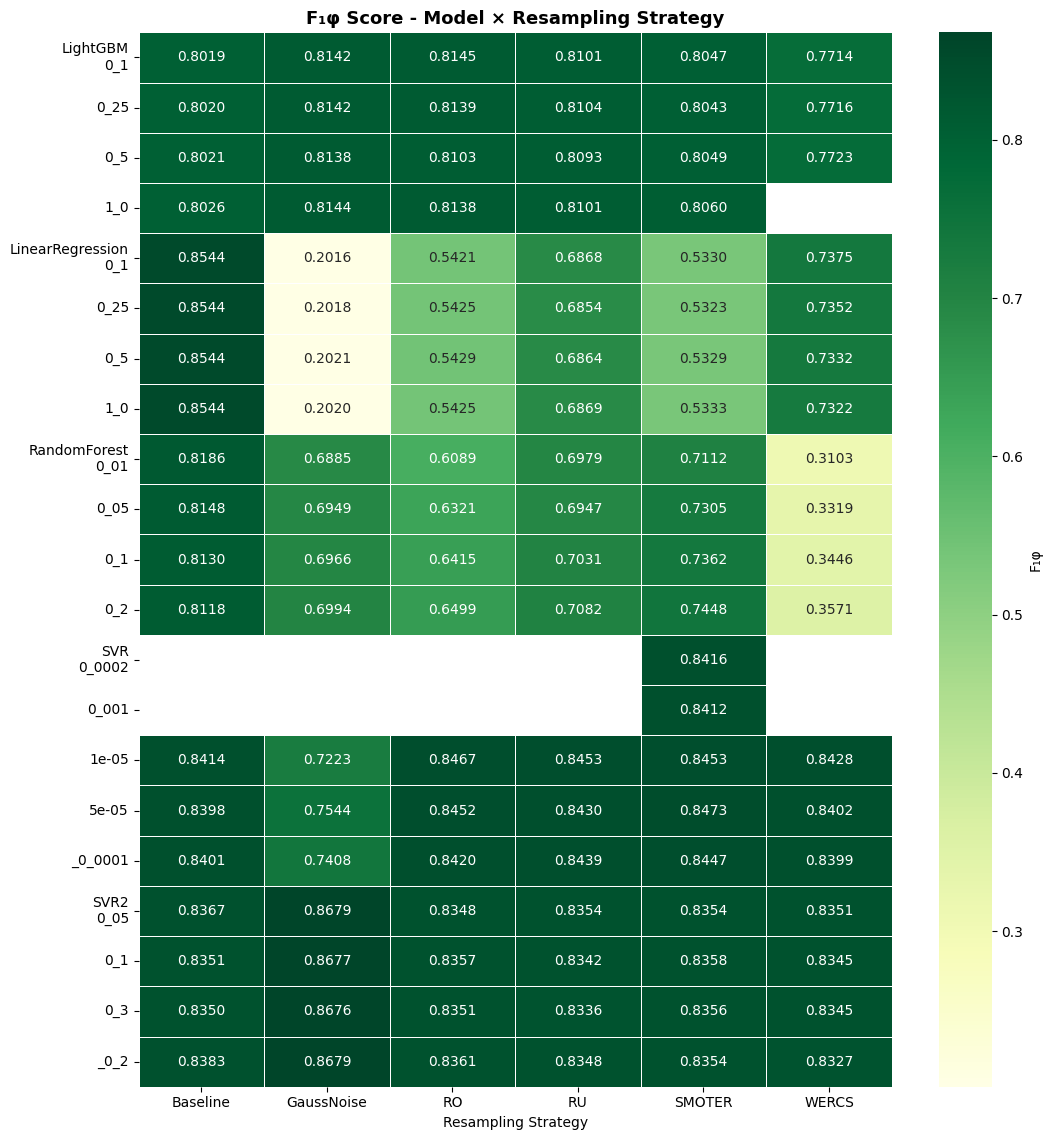

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

f1_pivot = results_df['f1_phi'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, len(f1_pivot) * 0.5 + 1))
sns.heatmap(
    f1_pivot,
    annot=True, fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'F₁φ'}
)

# show model name only on first row of each group
labels = []
for (model, sample) in f1_pivot.index:
    prev = f1_pivot.index[f1_pivot.index.get_loc((model, sample)) - 1] if f1_pivot.index.get_loc((model, sample)) > 0 else None
    labels.append(f'{model}\n{sample}' if prev is None or prev[0] != model else sample)

ax.set_yticklabels(labels, rotation=0)
ax.set_title('F₁φ Score - Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('results/f1.png')
plt.show()

### Precision & Recall φ - Grouped Bar Chart

C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\1367017263.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\1367017263.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\1367017263.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\1367017263.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\

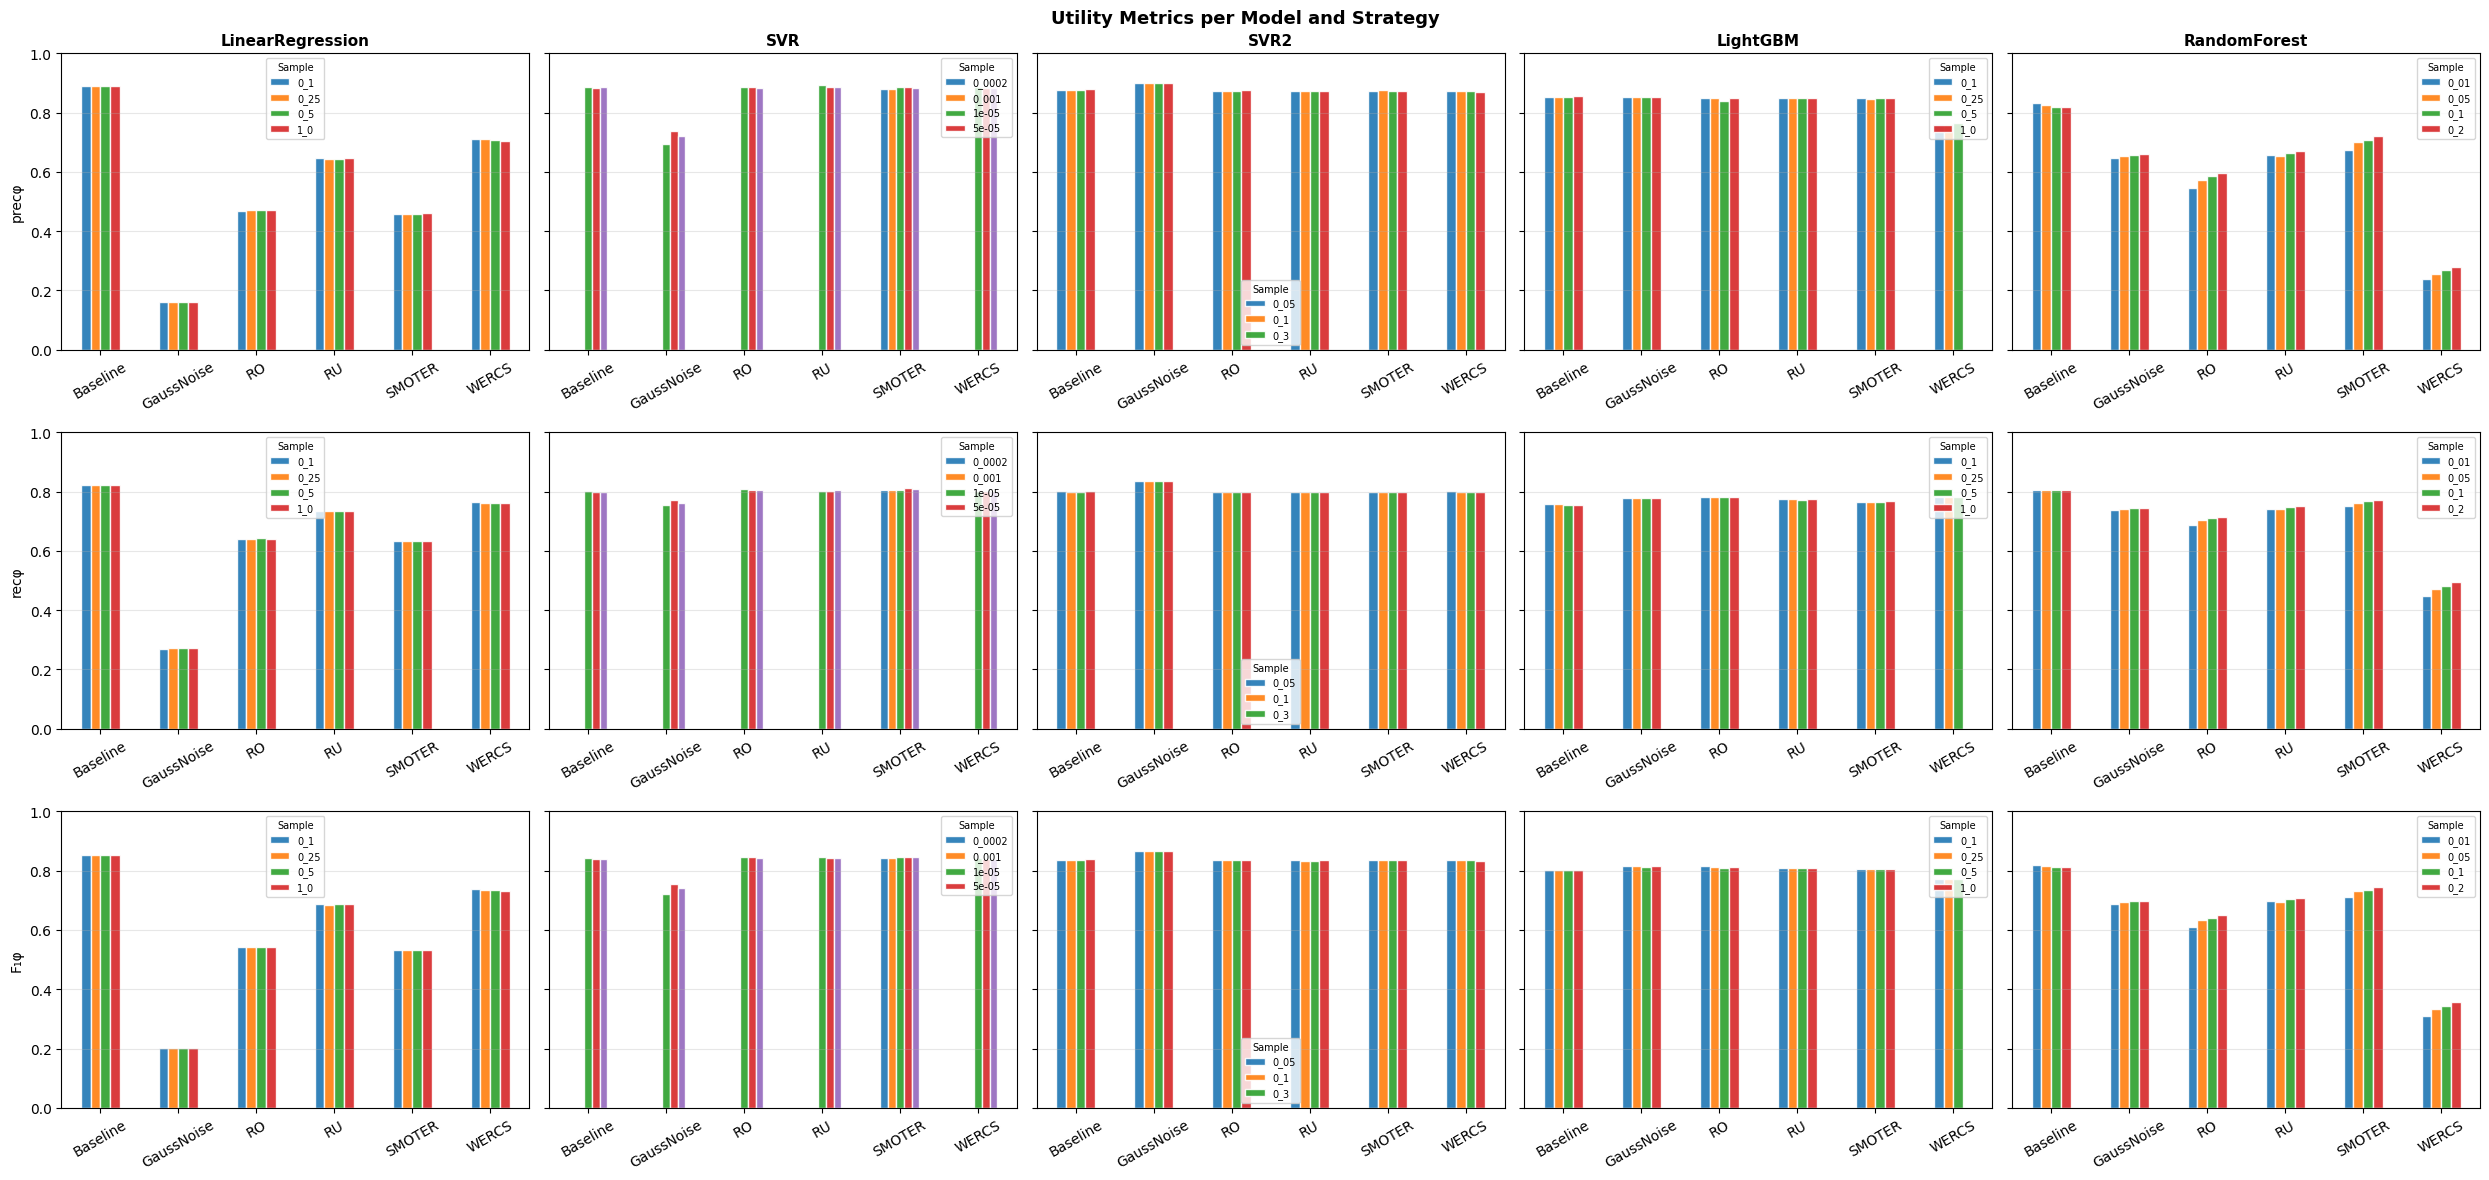

In [7]:
models_list  = results_df.index.get_level_values('Model').unique()
metrics      = ['prec_phi', 'rec_phi', 'f1_phi']
metric_names = ['precφ', 'recφ', 'F₁φ']

fig, axes = plt.subplots(
    len(metrics), len(models_list),
    figsize=(5 * len(models_list), 4 * len(metrics)),
    sharey='row', squeeze=False
)

for col, model_name in enumerate(models_list):
    for row, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        ax = axes[row][col]
        subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
        subset.plot.bar(ax=ax, edgecolor='white', alpha=0.9)

        if row == 0:
            ax.set_title(model_name, fontsize=11, weight='bold')
        if col == 0:
            ax.set_ylabel(metric_name, fontsize=10)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(title='Sample', fontsize=7, title_fontsize=7)

plt.suptitle('Utility Metrics per Model and Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('results/p&r.png', dpi=150)
plt.show()

### Overall MAE Comparison

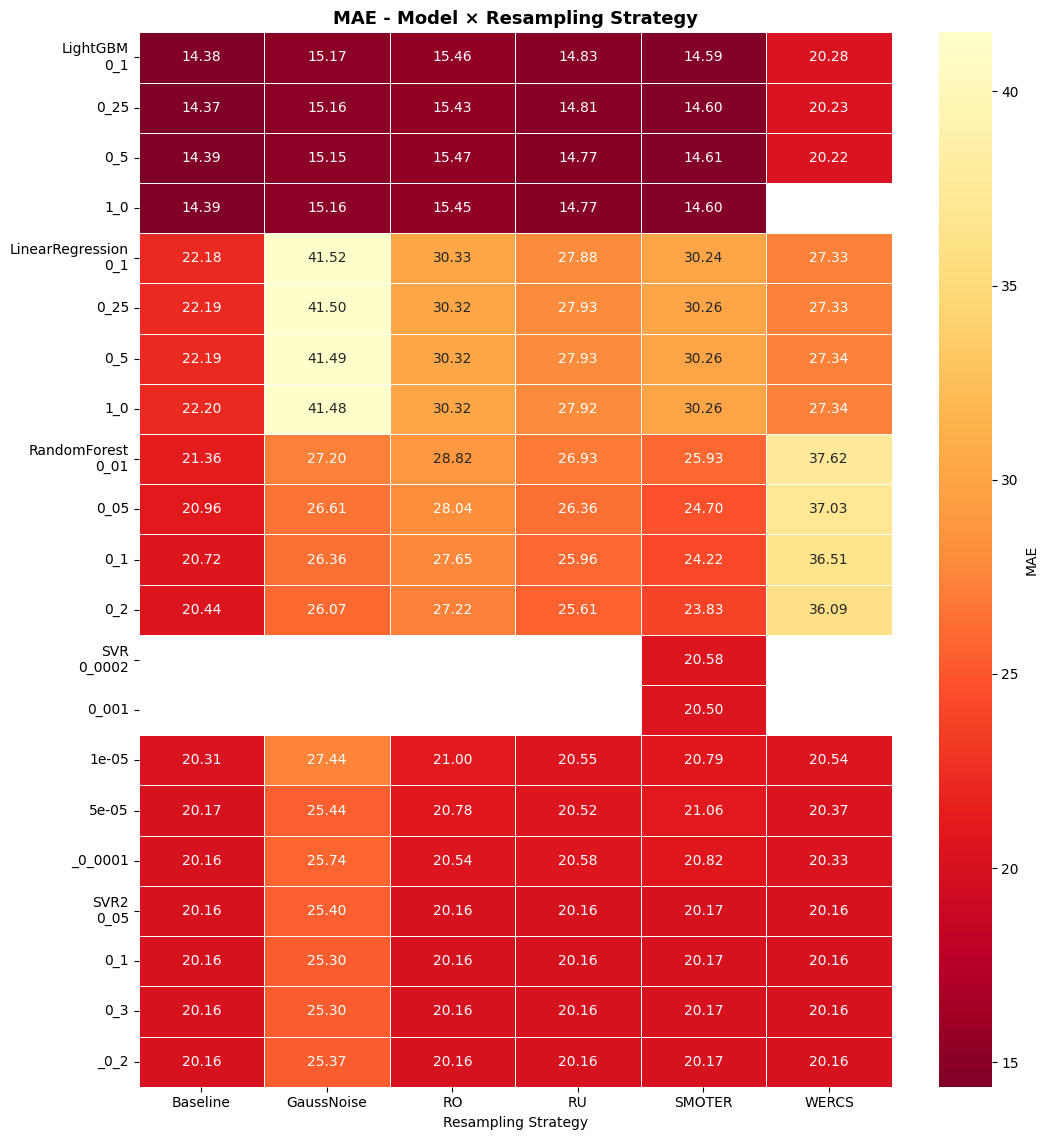

In [9]:
mae_pivot = results_df['MAE'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, len(mae_pivot) * 0.5 + 1))
sns.heatmap(
    mae_pivot,
    annot=True, fmt='.2f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'MAE'}
)

labels = []
for i, (model, sample) in enumerate(mae_pivot.index):
    prev = mae_pivot.index[i - 1] if i > 0 else None
    labels.append(f'{model}\n{sample}' if prev is None or prev[0] != model else sample)

ax.set_yticklabels(labels, rotation=0)
ax.set_title('MAE - Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('results/mae.png')
plt.show()

### Best Combination & Key Findings

In [11]:
best_idx     = results_df['f1_phi'].idxmax()
best_metrics = results_df.loc[best_idx]
print('=== Best combination by F₁φ ===')
print(f'  Model    : {best_idx[0]}')
print(f'  Sample   : {best_idx[1]}')
print(f'  Strategy : {best_idx[2]}')
print(f'  F₁φ      : {best_metrics["f1_phi"]:.4f}')
print(f'  precφ    : {best_metrics["prec_phi"]:.4f}')
print(f'  recφ     : {best_metrics["rec_phi"]:.4f}')
print(f'  MAE      : {best_metrics["MAE"]:.2f} min')
print(f'  RMSE     : {best_metrics["RMSE"]:.2f} min')
print()

rf_wercs_f1 = results_df.loc['RandomForest', 'f1_phi'].xs('WERCS', level='Strategy').max()
print(f'RandomForest + WERCS best F₁φ : {rf_wercs_f1:.4f}')
print(f'Hypothesis confirmed           : {best_idx[0] == "RandomForest" and best_idx[2] == "WERCS"}')
print()

print('=== Best strategy per model (by F₁φ) ===')
for model_name in models_list:
    best_idx_m  = results_df.loc[model_name, 'f1_phi'].idxmax()  # (sample, strategy)
    best_f1     = results_df.loc[(model_name, *best_idx_m), 'f1_phi']
    print(f'  {model_name:<20}: sample={best_idx_m[0]:<8} strategy={best_idx_m[1]:<12}  F₁φ={best_f1:.4f}')

=== Best combination by F₁φ ===
  Model    : SVR2
  Sample   : 0_05
  Strategy : GaussNoise
  F₁φ      : 0.8679
  precφ    : 0.9006
  recφ     : 0.8375
  MAE      : 25.40 min
  RMSE     : 51.03 min

RandomForest + WERCS best F₁φ : 0.3571
Hypothesis confirmed           : False

=== Best strategy per model (by F₁φ) ===
  LinearRegression    : sample=1_0      strategy=Baseline      F₁φ=0.8544
  SVR                 : sample=5e-05    strategy=SMOTER        F₁φ=0.8473
  SVR2                : sample=0_05     strategy=GaussNoise    F₁φ=0.8679
  LightGBM            : sample=0_1      strategy=RO            F₁φ=0.8145
  RandomForest        : sample=0_01     strategy=Baseline      F₁φ=0.8186


C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\138795345.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  rf_wercs_f1 = results_df.loc['RandomForest', 'f1_phi'].xs('WERCS', level='Strategy').max()
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_14012\138795345.py:21: PerformanceWarning: indexing past lexsort depth may impact performance.
  best_idx_m  = results_df.loc[model_name, 'f1_phi'].idxmax()  # (sample, strategy)


### Feature Importance - Random Forest + WERCS

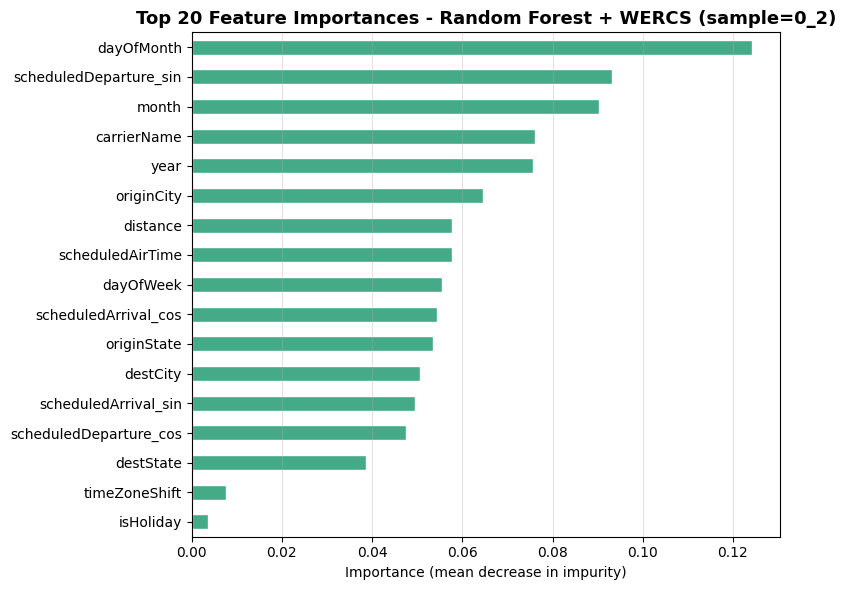

In [13]:
# pick the sample with best f1_phi for RandomForest + WERCS
best_sample = results_df.loc['RandomForest'].xs('WERCS', level='Strategy')['f1_phi'].idxmax()
rf_wercs = all_models[('RandomForest', best_sample, 'WERCS')]

fi = (
    pd.Series(rf_wercs.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(8, 6))
fi.sort_values().plot.barh(ax=ax, color='#44aa88', edgecolor='white')
ax.set_title(f'Top 20 Feature Importances - Random Forest + WERCS (sample={best_sample})', fontsize=13, weight='bold')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.savefig("results/fi_wercs_RF.png")

### Residual Distributions - Best Model per Strategy

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, strategy in zip(axes, strategies_list):
    best_idx_s   = results_df.xs(strategy, level='Strategy')['f1_phi'].idxmax()  # (model, sample)
    best_model_name, best_sample = best_idx_s
    model = all_models[(best_model_name, best_sample, strategy)]
    preds = np.clip(model.predict(X_test), 0, None)
    resid = y_test - preds
    ax.hist(resid, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f'{strategy}\n(best: {best_model_name} sample={best_sample})', fontsize=10, weight='bold')
    ax.set_xlabel('Residual (min)')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Residual Distributions - Best Model per Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("results/residual_distribution.png")